__Algoritno de para simular una cadena de Markov__ <br>
En este programa se simula una cadena de Markov que tiene $4$ estados los cuales representan los colores de un tablero. Inicialmente se hizo para el tablero de colores, pero el algoritmo es general y funciona con cualquier vector inicial y matriz $4x4$.   <br>
En clase el profesor nos dio un pseudocódigo que seguir para la implementación del algoritmo y es el siguiente: <br>
Entrada: $\alpha, P, n$ (número de pasos) <br>
Salida: $X_0, X_1, X_2, ..., X_n$ <br>
Generar $X_0$ de acuerdo a $\alpha$ <br>
Para $i = 1, 2, ..., n$ <br>
Si $X_{i-1} = j$ <br>
tomar $p =$ renglón j de $P$ <br>
Generar $X_i$ ~ $p$ <br>
Devolver <br>
Para iniciar el algoritmo primero se importan las librerias

In [3]:
import random
import matplotlib.pyplot as plt

Este fragmento de código realiza la inicialización de la cadena de Markov mediante la captura de datos del usuario. En la primera parte, se define el vector de estado inicial $\alpha$, que indica la probabilidad de comenzar en cada posición del sistema y en la segunda parte, se construye la matriz de transición $P$, la cual establece las probabilidades de moverse entre los cuatro estados posibles. 

In [4]:
alpha1=input("Digite la distribución inicial separado por comas:")
alpha=[float(x) for x in alpha1.split(",")]
P=[]
for i in range(4):
    fila=input(f"Digite la fila {i+1} de P separada por comas:")
    P.append([float(x) for x in fila.split(",")])

Digite la distribución inicial separado por comas: 0.25,0.25,0.25,0.25
Digite la fila 1 de P separada por comas: 0.25, 0.0, 0.25,0.5
Digite la fila 2 de P separada por comas: 0.5,0.25,0.0,0.25
Digite la fila 3 de P separada por comas: 0.25, 0.5, 0.25, 0.0
Digite la fila 4 de P separada por comas: 0.0,0.25,0.5,0.25


Este bloque define el estado inicial de la simulación usando un número aleatorio y las probabilidades del vector $\alpha$, el programa suma estas probabilidades para elegir al azar en cuál de los cuatro estados comienza el proceso.

In [5]:
n=10000
estados=[]
r=random.random()
sum=0
for i in range(4):
    sum=sum+alpha[i]
    if r<sum:
        estados.append(i)
        break

Aqui se realiza la simulación de los saltos entre estados para $n$ pasos en cada iteración, el programa identifica el estado actual y utiliza las probabilidades de la matriz de transición $P$ junto con un número aleatorio para determinar el siguiente estado y este proceso genera una secuencia de estados que representa el comportamiento de la cadena a lo largo del tiempo

In [6]:
for paso in range(1,n+1):
    esta=estados[paso-1]
    r=random.random()
    sum=0
    for j in range(4):
        sum=sum+P[esta][j]
        if r<sum:
            estados.append(j)
            break

En esta parte se le asigna un nombre de un color a cada estado los nombres de los colores que se usaron fueron del ejemplo del tablero que se hizo en clase y se imprimen los primeros $100$ pasos de la cadena.  

In [7]:
colores=["Naranja","Azul","Verde","Rojo"]
for i in range(100):
    print(f"Paso {i}={colores[estados[i]]}")

Paso 0=Naranja
Paso 1=Rojo
Paso 2=Verde
Paso 3=Verde
Paso 4=Azul
Paso 5=Naranja
Paso 6=Rojo
Paso 7=Verde
Paso 8=Naranja
Paso 9=Rojo
Paso 10=Rojo
Paso 11=Azul
Paso 12=Naranja
Paso 13=Verde
Paso 14=Naranja
Paso 15=Rojo
Paso 16=Verde
Paso 17=Naranja
Paso 18=Verde
Paso 19=Naranja
Paso 20=Rojo
Paso 21=Rojo
Paso 22=Verde
Paso 23=Azul
Paso 24=Naranja
Paso 25=Naranja
Paso 26=Rojo
Paso 27=Rojo
Paso 28=Azul
Paso 29=Rojo
Paso 30=Verde
Paso 31=Azul
Paso 32=Rojo
Paso 33=Verde
Paso 34=Verde
Paso 35=Naranja
Paso 36=Rojo
Paso 37=Verde
Paso 38=Azul
Paso 39=Naranja
Paso 40=Rojo
Paso 41=Azul
Paso 42=Naranja
Paso 43=Rojo
Paso 44=Verde
Paso 45=Azul
Paso 46=Naranja
Paso 47=Verde
Paso 48=Verde
Paso 49=Azul
Paso 50=Rojo
Paso 51=Azul
Paso 52=Azul
Paso 53=Rojo
Paso 54=Verde
Paso 55=Azul
Paso 56=Azul
Paso 57=Naranja
Paso 58=Naranja
Paso 59=Verde
Paso 60=Naranja
Paso 61=Naranja
Paso 62=Rojo
Paso 63=Azul
Paso 64=Azul
Paso 65=Naranja
Paso 66=Rojo
Paso 67=Azul
Paso 68=Naranja
Paso 69=Rojo
Paso 70=Verde
Paso 71=Azul


En este fragmento de código se hace una gráfica de los primeros 1000 pasos, donde:
- Eje $x$: número de paso
- Eje $y$: estado
- La línea morada permite ver cómo la cadena se mueve entre los estados <br>
Esta gráfica se hizo para ver la evolución de la cadena y comprobar la distribución de los estados.

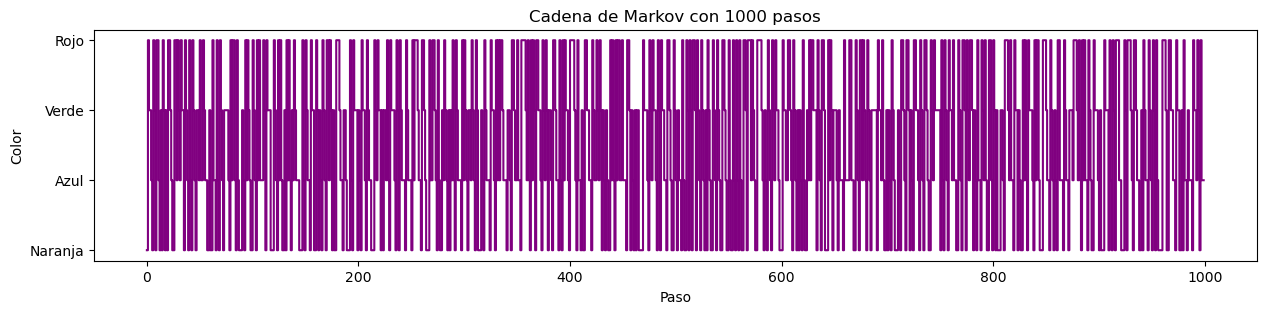

In [8]:
plt.figure(figsize=(15,3))
plt.step(range(1000), estados[:1000], where='post', color='purple')
plt.yticks([0,1,2,3], colores)
plt.xlabel("Paso")
plt.ylabel("Color")
plt.title("Cadena de Markov con 1000 pasos")
plt.show()

Este bloque cuenta las apariciones de cada estado y calcula su porcentaje sobre el total de pasos $n$ y el objetivo es observar cómo, tras muchas repeticiones, los estados tienden a estabilizarse

In [13]:
cont=[0,0,0,0]
for i in estados:
    cont[i]=cont[i]+1
porcen=[0,0,0,0]
for i in range(4):
    porcen[i]=cont[i]/n*100
    print(colores[i]+":"+str(round(porcen[i],2))+"%")

Naranja:24.86%
Azul:25.57%
Verde:24.17%
Rojo:25.41%


Los resultados dejan ver que después de muchos pasos, los cuatro colores se reparten de manera parecida, cerca del $25$% cada uno. Esto indica que la cadena se estabiliza, y que con suficiente tiempo, todos los colores aparecen casi por igual, sin importar desde dónde comenzamos. Esto me ayudo a entender cómo con el tiempo todos los colores se reparten de manera equilibrada y lo interesante es que esto no solo pasa en este caso, sino que es algo que sucede en cualquier cadena de Markov similar, mostrando cómo estos sistemas tienden a un comportamiento constante a largo plazo.